In [4]:

# importing model

In [3]:
import pandas as pd 
import numpy as np 
import  seaborn as sns 
import plotly.express as px 
import matplotlib.pyplot  as  plt 
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from sklearn.svm import SVC
from xgboost import XGBRFClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import joblib

In [4]:
df = pd.read_csv('C:/Users/acer/Desktop/Tyroid disease prediction/Thyroid_Diff.csv',low_memory=True)

In [5]:
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [7]:
df.rename(columns={'T':'Tumor','N':'Nodal','M':'Metastasis'},inplace=True)

In [8]:
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,Tumor,Nodal,Metastasis,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [9]:
df.columns

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'Tumor', 'Nodal', 'Metastasis', 'Stage', 'Response',
       'Recurred'],
      dtype='object')

In [15]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,Tumor,Nodal,Metastasis,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [10]:
df.isnull().sum()   

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
Tumor                   0
Nodal                   0
Metastasis              0
Stage                   0
Response                0
Recurred                0
dtype: int64

In [11]:
df.nunique()   # type dinx ram hari ram hari nunique values is 2.

Age                     65
Gender                   2
Smoking                  2
Hx Smoking               2
Hx Radiothreapy          2
Thyroid Function         5
Physical Examination     5
Adenopathy               6
Pathology                4
Focality                 2
Risk                     3
Tumor                    7
Nodal                    3
Metastasis               2
Stage                    5
Response                 4
Recurred                 2
dtype: int64

In [12]:
# main EDA
#1.AGE ANALYSIS
fig = px.histogram(data_frame=df,
                   x ='Age',
                   nbins=20,marginal='box',
                    color_discrete_sequence=px.colors.sequential.GnBu_r,
                   text_auto=True,title='The Distribution of Age')
fig.update_layout()
fig.show()

In [13]:
fig = px.histogram(data_frame=df,
                   x ='Age',
                   nbins=20,marginal='box',
                   color='Recurred',
                   color_discrete_sequence=px.colors.sequential.Agsunset_r,
                   text_auto=True,title='The Distribution of Recurred based on Age')
fig.update_layout()
fig.show()

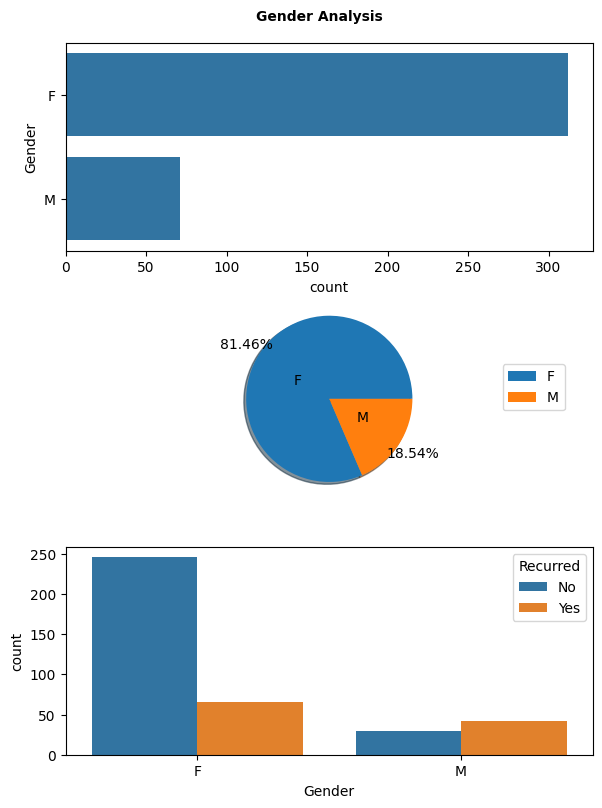

In [14]:
#on the basis of gender

fig, ax = plt.subplots(3, 1, figsize=(6, 8))
fig.suptitle('Gender Analysis', fontsize=10, fontweight='bold')
plt.tight_layout()

count = df['Gender'].value_counts()

labels = df['Gender'].value_counts().index.tolist()

#Top ax
sns.countplot(y="Gender",data=df, ax=ax[0])
#middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Gender', hue='Recurred', data=df, ax=ax[2])
plt.show()

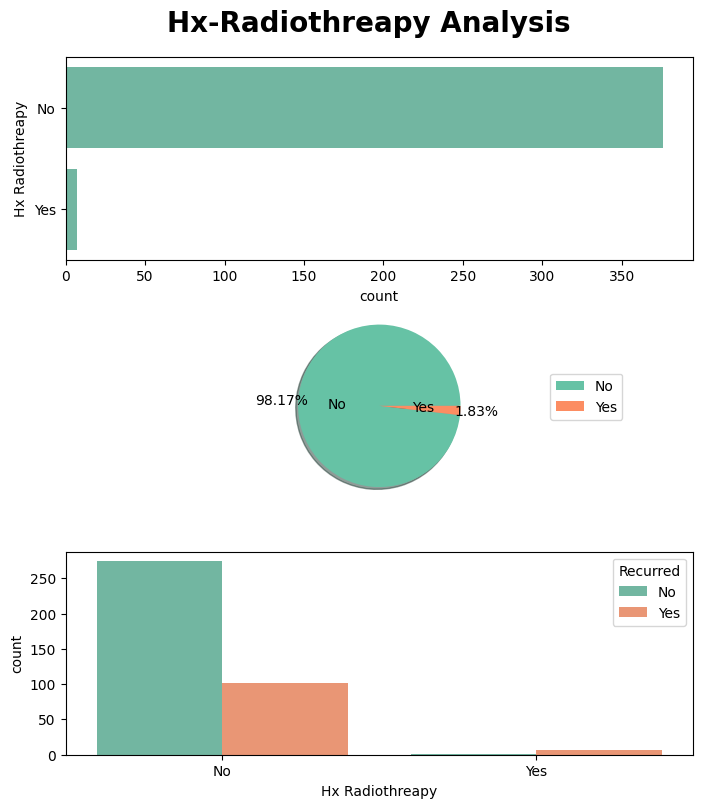

In [15]:
# radio therapy analysis
sns.set_palette('Set2')
fig, ax = plt.subplots(3, 1, figsize=(7, 8))
fig.suptitle('Hx-Radiothreapy Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df['Hx Radiothreapy'].value_counts()

labels = df['Hx Radiothreapy'].value_counts().index.tolist()

#Top ax
sns.countplot(y="Hx Radiothreapy",data=df, ax=ax[0])
#middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Hx Radiothreapy', hue='Recurred', data=df, ax=ax[2])
plt.show()

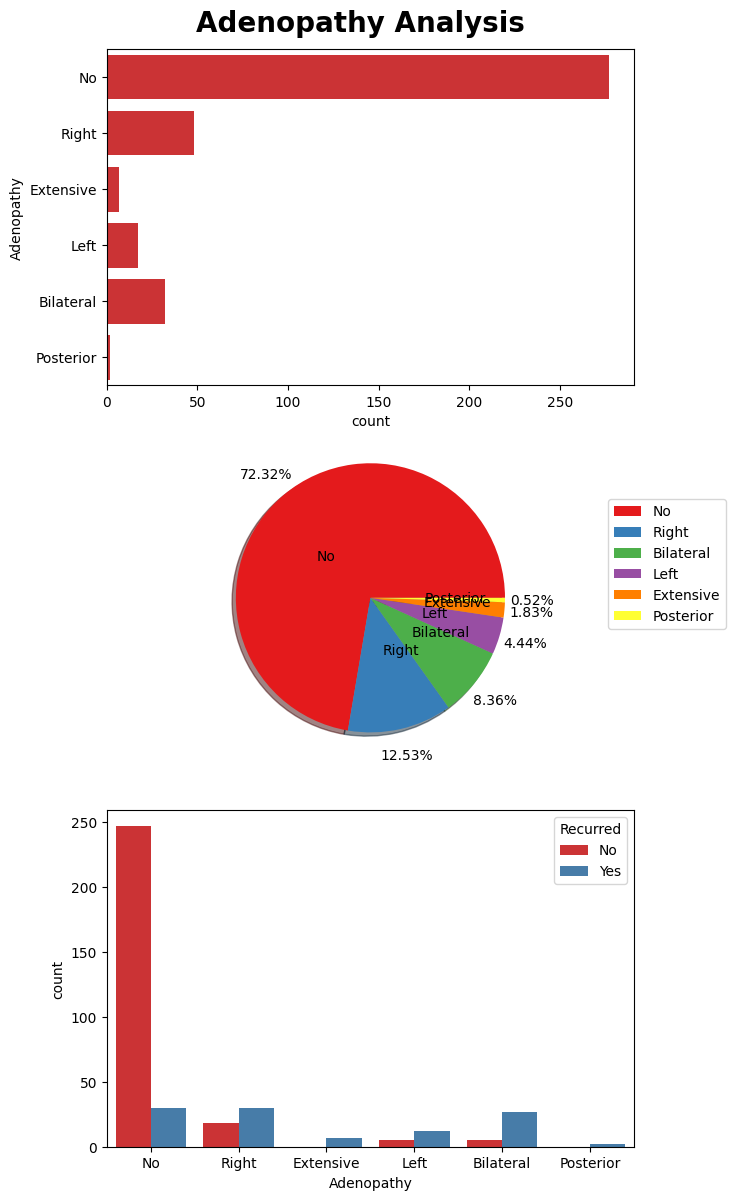

In [16]:
# adinopathy analysis
sns.set_palette('Set1')
fig, ax = plt.subplots(3, 1, figsize=(6, 12))
fig.suptitle('Adenopathy Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df.Adenopathy.value_counts()

labels = df.Adenopathy.value_counts().index.tolist()

#Top ax
sns.countplot(y="Adenopathy",data=df, ax=ax[0])
#middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Adenopathy', hue='Recurred', data=df, ax=ax[2])
plt.show()

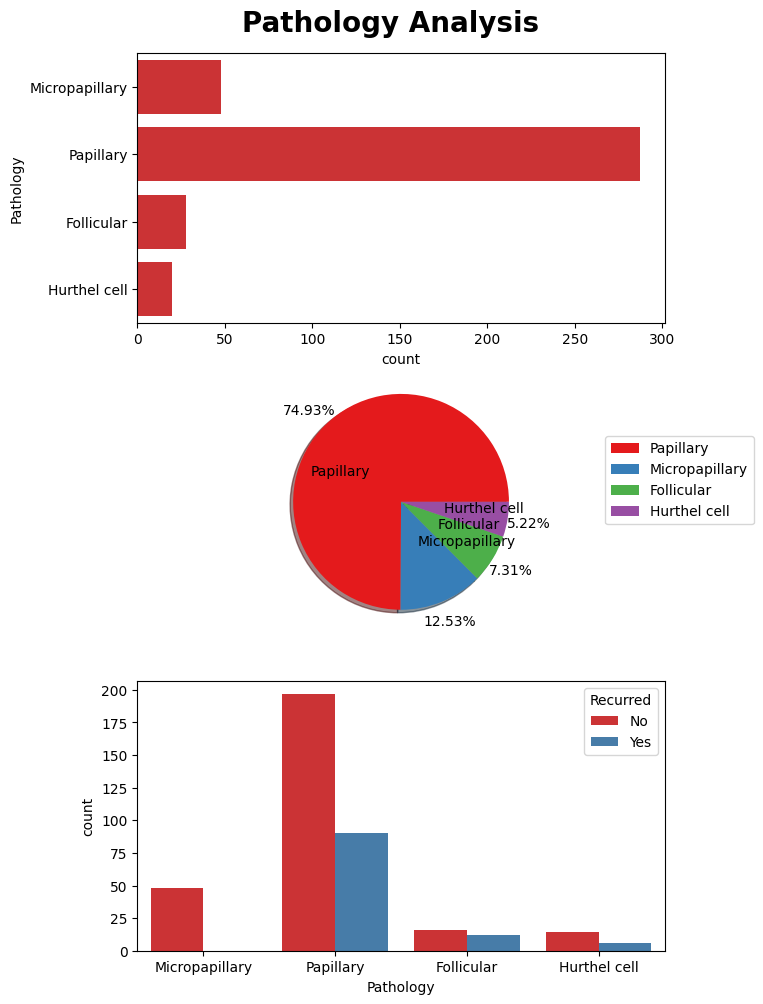

In [17]:
# pathology analysis    
fig, ax = plt.subplots(3, 1, figsize=(6, 10))
fig.suptitle('Pathology Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df.Pathology.value_counts()

labels = df.Pathology.value_counts().index.tolist()

#Top ax
sns.countplot(y="Pathology",data=df, ax=ax[0])
#middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Pathology', hue='Recurred', data=df, ax=ax[2])
plt.show()

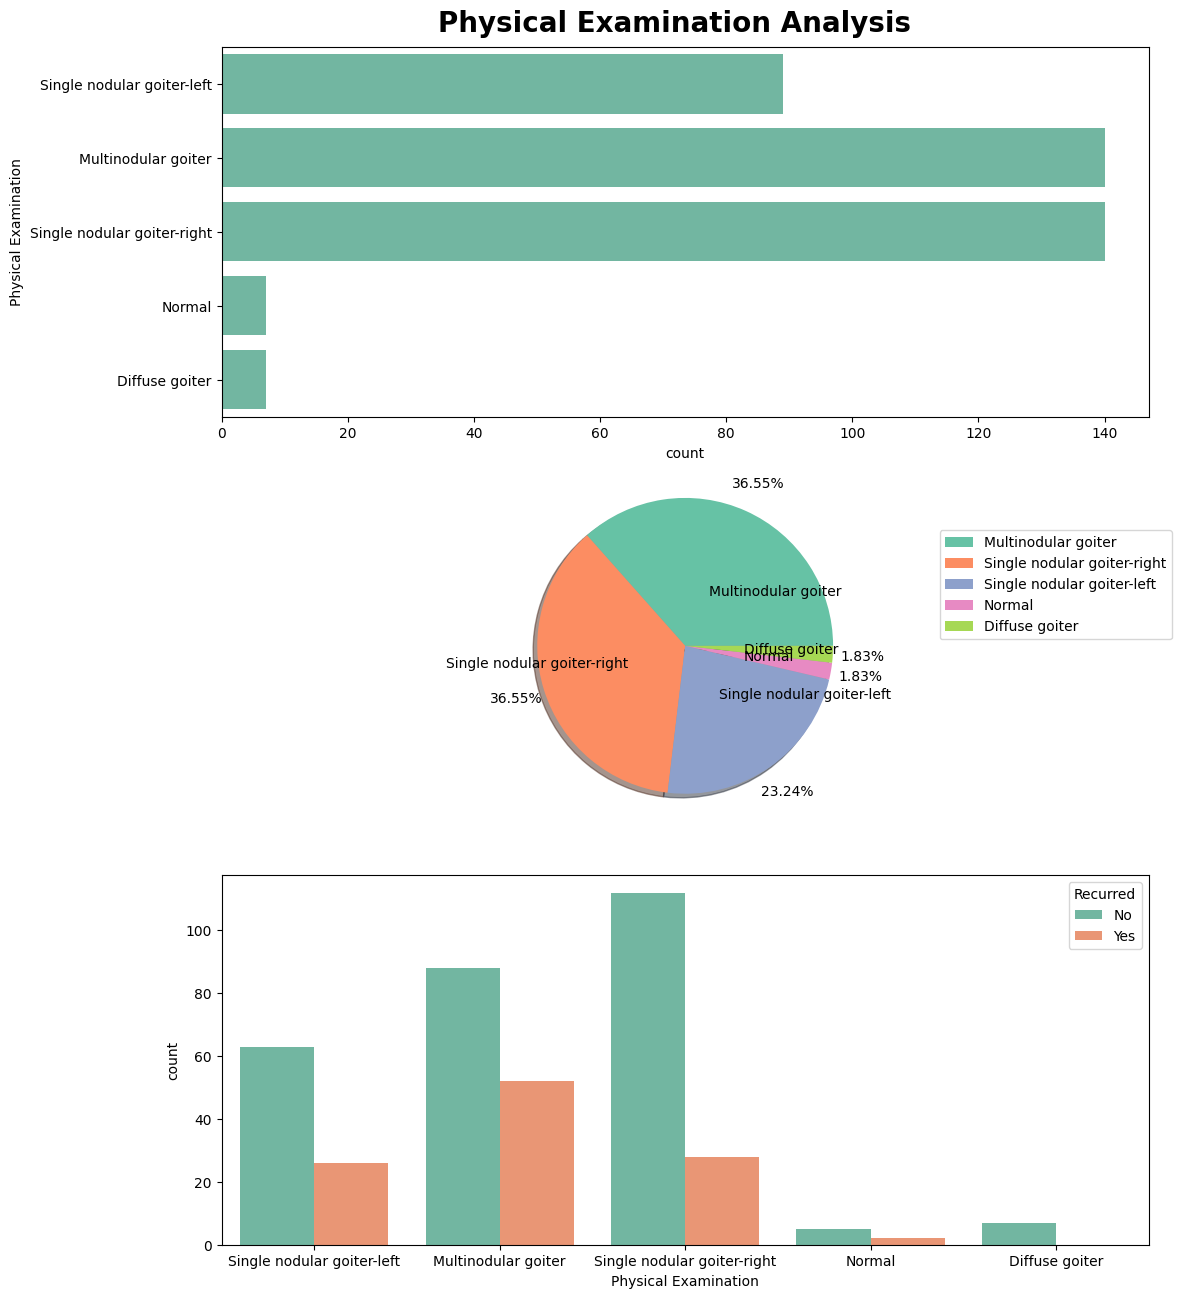

In [18]:
#physical examination analysis  
sns.set_palette('Set2')
fig, ax = plt.subplots(3, 1, figsize=(10, 13))
fig.suptitle('Physical Examination Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df['Physical Examination'].value_counts()

labels = df['Physical Examination'].value_counts().index.tolist()

#Top ax
sns.countplot(y="Physical Examination",data=df, ax=ax[0])
#Middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Physical Examination', hue='Recurred', data=df, ax=ax[2])
plt.show()

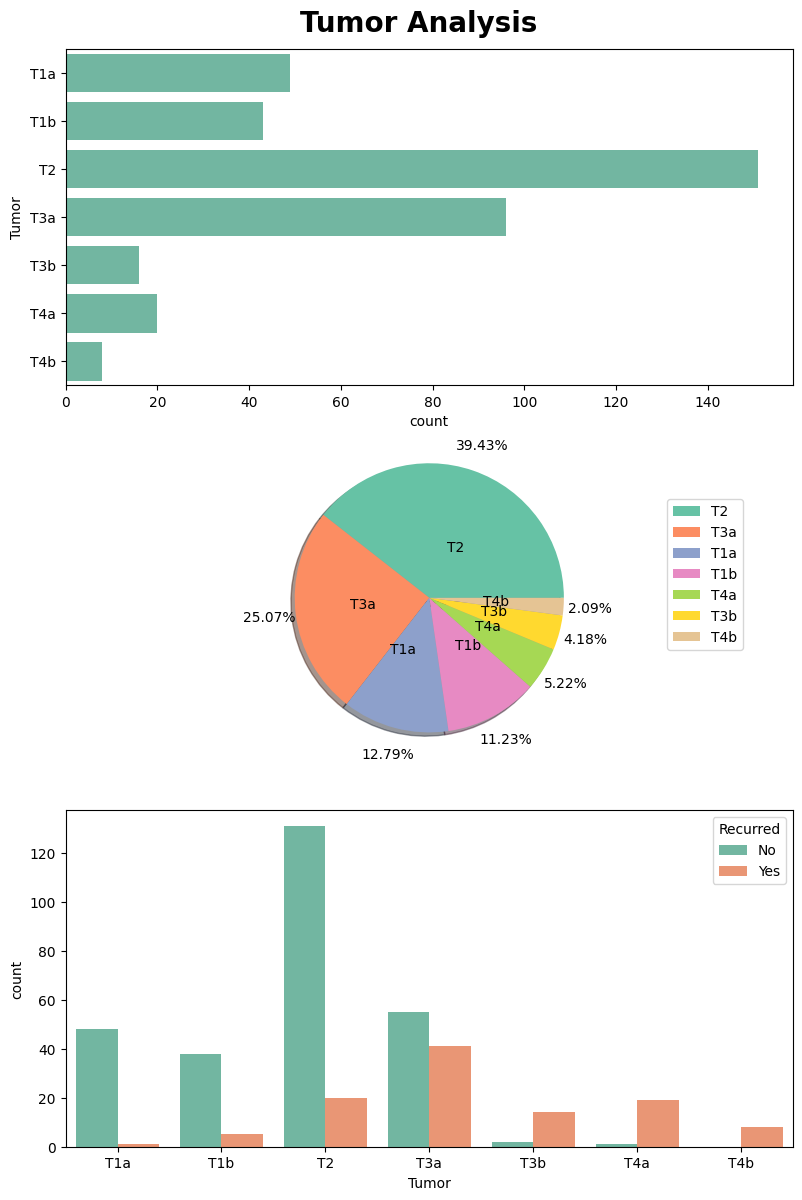

In [19]:
# tumor analysis    
sns.set_palette('Set2')
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
fig.suptitle('Tumor Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df.Tumor.value_counts()

labels = df.Tumor.value_counts().index.tolist()

#Top ax
sns.countplot(y="Tumor",data=df, ax=ax[0])
#middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Tumor', hue='Recurred', data=df, ax=ax[2])
plt.show()

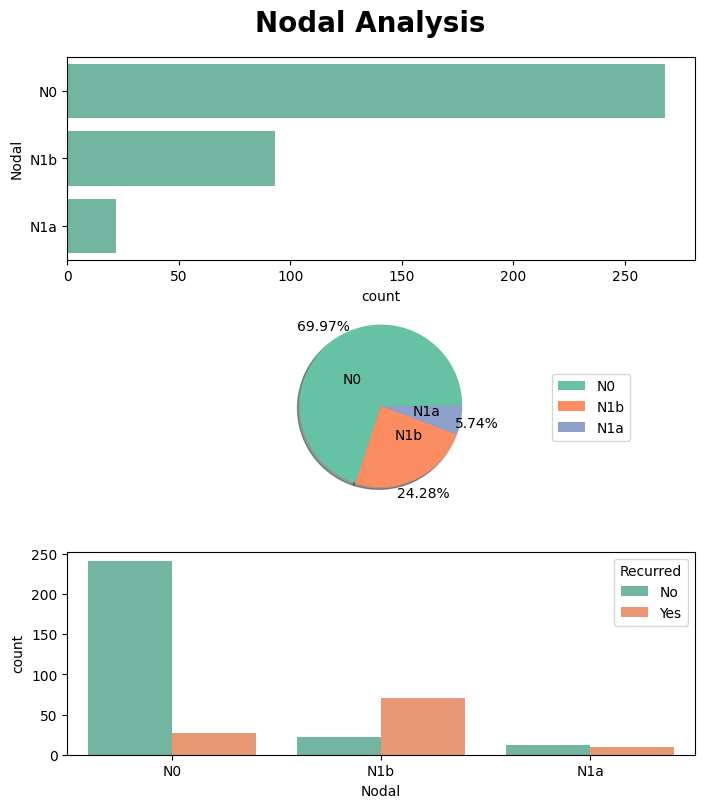

In [20]:
# nodal analysis
sns.set_palette('Set2')
fig, ax = plt.subplots(3, 1, figsize=(7, 8))
fig.suptitle('Nodal Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df.Nodal.value_counts()

labels = df.Nodal.value_counts().index.tolist()
#Top ax
sns.countplot(y="Nodal",data=df, ax=ax[0])
#Middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Nodal', hue='Recurred', data=df, ax=ax[2])
plt.show()

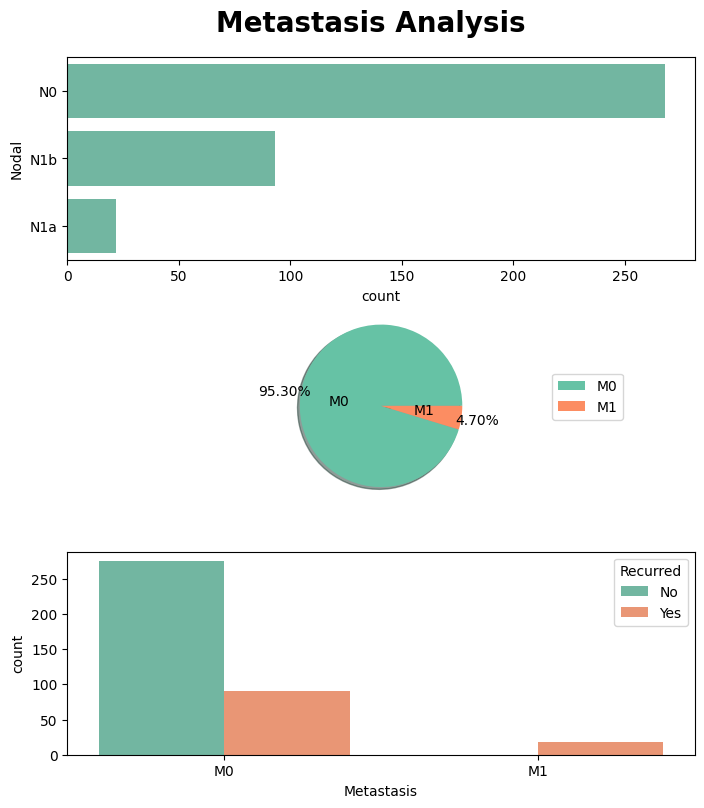

In [21]:
# metastatsis analysis
sns.set_palette('Set2')
fig, ax = plt.subplots(3, 1, figsize=(7, 8))
fig.suptitle('Metastasis Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()

count = df.Metastasis.value_counts()



labels = df.Metastasis.value_counts().index.tolist()
#Top ax
sns.countplot(y="Nodal",data=df, ax=ax[0])
#Middle ax
ax[1].pie(count, autopct='%.2f%%', labels=labels, shadow=True, pctdistance=1.2, labeldistance=0.4)
ax[1].legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=5)

# Bottom ax
sns.countplot(x='Metastasis', hue='Recurred', data=df, ax=ax[2])
plt.show()  

In [22]:
# data processing
#split data
inputs_df = df.drop('Recurred',axis=1)
targets_df= df[['Recurred']]

In [23]:
categorical_cols = inputs_df.select_dtypes(include='object').columns.tolist()
categorical_cols

['Gender',
 'Smoking',
 'Hx Smoking',
 'Hx Radiothreapy',
 'Thyroid Function',
 'Physical Examination',
 'Adenopathy',
 'Pathology',
 'Focality',
 'Risk',
 'Tumor',
 'Nodal',
 'Metastasis',
 'Stage',
 'Response']

In [25]:
#Preprocessing categorical data # categotical data lai binary form ma lageko 1 or o
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(inputs_df[categorical_cols])
encoder_cols = encoder.get_feature_names_out(categorical_cols)
inputs_df[encoder_cols] =encoder.transform(inputs_df[categorical_cols])

In [26]:
# concatinate the numeric data numeric colum ma divide hunx axis=0 row wise concat and axix=1 cols wise
final_df = pd.concat([inputs_df['Age'],inputs_df[encoder_cols]],axis=1)

In [27]:
# age lai scale garne:: MinMaxScaler le data lai 0 to 1 range ma scale garxa.
scaler = MinMaxScaler()
final_df[['Age']] = scaler.fit_transform(final_df[['Age']])

In [28]:
 X = final_df # input / features    
 y= targets_df # y target/label/dependent variable

In [37]:
X

,Age,Gender_F,Gender_M,Smoking_No,Smoking_Yes,Hx Smoking_No,Hx Smoking_Yes,Hx Radiothreapy_No,Hx Radiothreapy_Yes,Thyroid Function_Clinical Hyperthyroidism,...,Metastasis_M1,Stage_I,Stage_II,Stage_III,Stage_IVA,Stage_IVB,Response_Biochemical Incomplete,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete
0,0.179104,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.283582,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.223881,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.701493,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.701493,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,0.850746,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
379,0.985075,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
380,0.850746,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
381,0.686567,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [29]:
y

,Recurred
0,No
1,No
2,No
3,No
4,No
...,...
378,Yes
379,Yes
380,Yes
381,Yes


In [30]:
# modeling
# cross validation spliting data into train and test
# Suppose X = [Age, Gender_Male, City_Kathmandu] ra y = Recurred
#xtrain = first 80% rows of [Age, Gender_Male, City_Kathmandu]
#ytrain = first 80% rows of Recurred
#xtest = last 20% rows of [Age, Gender_Male, City_Kathmandu]
#ytest = last 20% rows of Recurred

xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=.20,random_state=42)

In [31]:
# Analysis a model performance
logist = LogisticRegression()
logist.fit(xtrain,ytrain)

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
logist.predict(xtest)

array(['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'Yes'], dtype=object)

In [33]:
print(classification_report(ytest,logist.predict(xtest)))
# recision = 0.98 → Model le predict gareko “No” ma 98% sahi ho.
#Recall = 0.98 → Actual “No” ma 98% sahi identify gareko.
#F1-score = 0.98 → Precision ra recall ko harmonic mean.

              precision    recall  f1-score   support

          No       0.98      0.98      0.98        58
         Yes       0.95      0.95      0.95        19

    accuracy                           0.97        77
   macro avg       0.97      0.97      0.97        77
weighted avg       0.97      0.97      0.97        77



In [34]:
cm = confusion_matrix(ytest,logist.predict(xtest))
cm

array([[57,  1],
       [ 1, 18]])

In [35]:
accuracy_score(ytest,logist.predict(xtest))

0.974025974025974

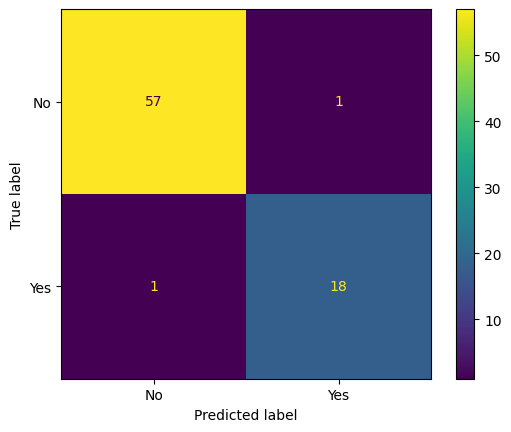

In [48]:
fig = ConfusionMatrixDisplay(cm,display_labels=logist.classes_)
fig.plot()